# Fork (bifurcation) term — the four questions

George (2026-07-04): (1) eff/far vs original, classical AND 1BQF; (2) extra qubits +
2-qubit gates; (3) sparsity; (4) activation peak structure. **Step kernel only.**

Data: `results/dp_{pilot,working_points,costs,classical_spectrum}.csv` — pilot commit
`a3379c18`, costs/working-points `dbbb769a`+. Operating point: σ_scatt=1e-4,
σ_res=10 µm, drop=1%, φ_max=0.2, formula ε=3.178 mrad, γ=3, δ=1.

In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BIF = Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Bifurification")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False})
P  = pd.read_csv(BIF / "results" / "dp_pilot.csv")            # pilot: classical attractor-tau + 1BQF
WP = pd.read_csv(BIF / "results" / "dp_working_points.csv")   # fair tau-sweep working points + peaks
CO = pd.read_csv(BIF / "results" / "dp_costs.csv")            # qubits / cx / sparsity
SP = (pd.read_csv(BIF / "results" / "dp_classical_spectrum.csv")
      if (BIF / "results" / "dp_classical_spectrum.csv").exists() else None)
print(f"pilot {len(P)} rows | working points {len(WP)} | costs {len(CO)} | "
      f"spectral {'pending' if SP is None else len(SP)}")
CONFS = ['fork b=0.5', 'fork b=1']
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


pilot 72 rows | working points 36 | costs 20 | spectral pending


## Q1 — does the fork term improve efficiency / false rate vs the original?

**Classical, fair comparison** (matched events, per-config τ-sweep — the attractor τ is
NOT a fair yardstick, it mis-centres under occupancy): AUC and the false rate at the
99% / 95%-efficiency working points. Mean AND median over reps (T=200 rep 1 is a
genuinely hard event — far@eff99 ≈ 0.98 for *every* config including base — so the
median is the robust read).

--- mean over reps ---
                  auc  far_eff99  far_eff95
T   config                                 
100 base       1.0000     0.0280     0.0062
    fork b=0.5 1.0000     0.0321     0.0009
    fork b=1   0.9983     0.0335     0.0009
200 base       0.9973     0.4089     0.0175
    fork b=0.5 0.9975     0.3964     0.0066
    fork b=1   0.9955     0.5257     0.0066 

--- median over reps ---
                  auc  far_eff99  far_eff95
T   config                                 
100 base       1.0000     0.0050     0.0052
    fork b=0.5 1.0000     0.0000     0.0000
    fork b=1   1.0000     0.0000     0.0000
200 base       0.9987     0.2118     0.0195
    fork b=0.5 0.9988     0.1819     0.0092
    fork b=1   0.9963     0.2978     0.0092 



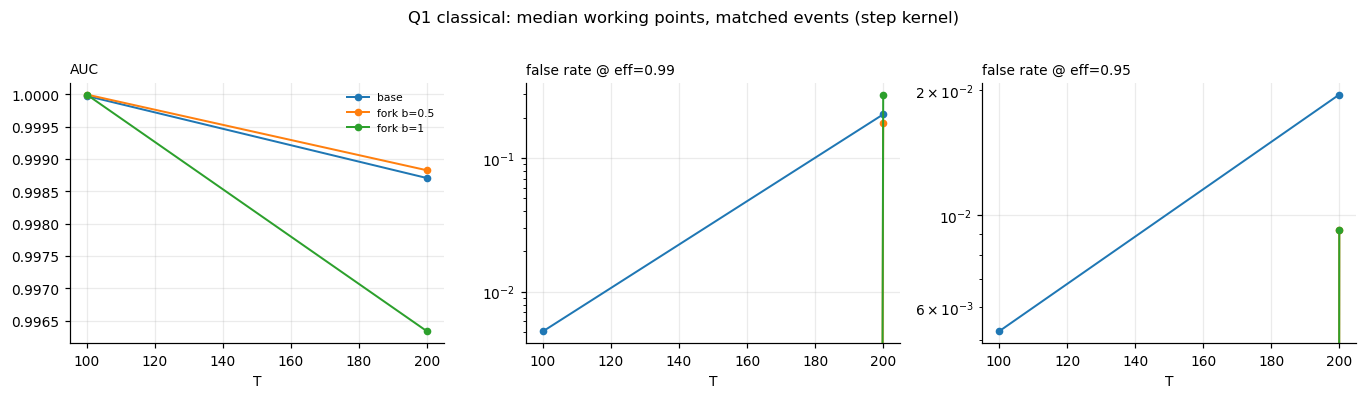

In [2]:
sel = WP[WP.config.isin(["base"] + CONFS)]
for stat in ["mean", "median"]:
    t = sel.groupby(["T", "config"])[["auc", "far_eff99", "far_eff95"]].agg(stat)
    print(f"--- {stat} over reps ---"); print(t.to_string(), "\n")
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.5))
for ax, col, lab in zip(axes, ["auc", "far_eff99", "far_eff95"],
                        ["AUC", "false rate @ eff=0.99", "false rate @ eff=0.95"]):
    for cfg in ["base"] + CONFS:
        g = sel[sel.config == cfg].groupby("T")[col].median()
        ax.plot(g.index, g.values, marker="o", ms=4, lw=1.3, label=cfg)
    if col != "auc":
        ax.set_yscale("log")
    ax.set_xlabel("T"); ax.set_title(lab, loc="left", fontsize=9)
axes[0].legend(fontsize=7)
fig.suptitle("Q1 classical: median working points, matched events (step kernel)", y=1.02)
fig.tight_layout(); plt.show()

**1BQF side** (pilot, same events; the 1BQF is run AS-IS — no retuning for the shifted
spectrum, which the classical-first spectral study shows is the actual blocker):

In [3]:
q = P[(P.alpha == 0) & (P["T"] <= 200)]
t = q.groupby(["T", "beta"])[["far_Qwp", "auc_Q", "cos_QC"]].mean()
print("1BQF wp99 false rate / AUC / cos vs classical (as-is, no retune):")
print(t.to_string())

1BQF wp99 false rate / AUC / cos vs classical (as-is, no retune):
            far_Qwp  auc_Q  cos_QC
T   beta                          
50  0.0000   0.0099 0.9999  0.2216
    0.5000   0.0099 0.9999  0.2216
    1.0000   0.0099 0.9999  0.2216
    2.0000   0.0099 0.9999  0.2216
100 0.0000   0.1033 0.9997  0.1641
    0.5000   0.4611 0.9967  0.1868
    1.0000   0.4611 0.9967  0.1815
    2.0000   0.4611 0.9967  0.1736
200 0.0000   0.5345 0.9968  0.1284
    0.5000   0.8962 0.9900  0.1899
    1.0000   0.8962 0.9900  0.1781
    2.0000   0.8962 0.9900  0.1602


## Q2 — extra 1BQF cost: qubits and 2-qubit gates

Real transpiled `OneBitHHL` circuits (basis cx/rz/sx/x) at small T; the circuit applies
one n_sys-controlled RX per interaction pair, so cx counts are pair-proportional
(measured ~250/pair at n_sys=9, ~319/pair at n_sys=11 — grows with n_sys).

In [4]:
cols = ["T", "config", "n_seg", "pairs", "pairs_vs_base", "n_qubits", "cx", "cx_per_pair"]
have = [c for c in cols if c in CO.columns]
print(CO[CO.config.isin(["base"] + [c.split()[0] for c in CONFS] + ["fork", "occ", "both"])][have]
      .to_string(index=False))
print("\nQubits: IDENTICAL for every config at every T (the term changes couplings, "
      "not the state dimension) -> extra qubit cost = 0.")

  T config  n_seg    pairs  pairs_vs_base  n_qubits          cx  cx_per_pair
 10   base    400       31         1.0000   11.0000   7763.0000     250.4194
 10   fork    400       31         1.0000   11.0000   7763.0000     250.4194
 10    occ    400     3631       117.1290   11.0000 901921.0000     248.3947
 10   both    400     3631       117.1290   11.0000 901921.0000     248.3947
 20   base   1540       58         1.0000   13.0000  18517.0000     319.2586
 20   fork   1540       58         1.0000   13.0000  18517.0000     319.2586
 20    occ   1540    28748       495.6552       NaN         NaN          NaN
 20   both   1540    28748       495.6552       NaN         NaN          NaN
 50   base   9900      149         1.0000       NaN         NaN          NaN
 50   fork   9900      149         1.0000       NaN         NaN          NaN
 50    occ   9900   482799      3240.2617       NaN         NaN          NaN
 50   both   9900   482799      3240.2617       NaN         NaN          NaN

## Q3 — sparsity of the modified matrix

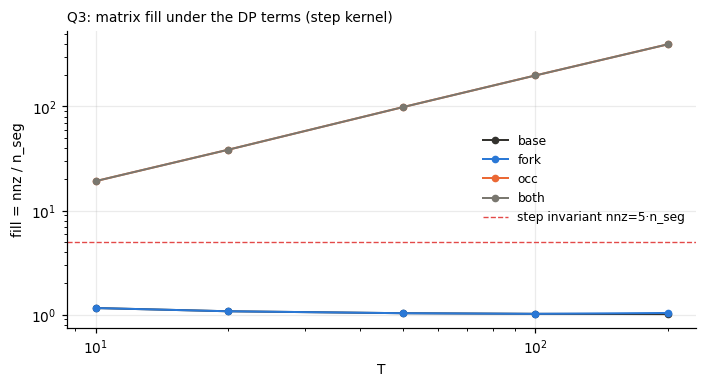

config   base     both   fork      occ
T                                     
10     1.1550  19.1550 1.1550  19.1550
20     1.0753  38.3351 1.0753  38.3351
50     1.0301  98.5352 1.0301  98.5352
100    1.0161 198.5186 1.0161 198.5186
200    1.0097 395.2607 1.0358 395.2607


In [5]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for cfg, c in [("base", "#33322e"), ("fork", "#2a78d6"), ("occ", "#eb6834"), ("both", "#79776f")]:
    g = CO[CO.config == cfg].set_index("T")
    ax.loglog(g.index, g.fill, marker="o", ms=4, lw=1.3, color=c, label=cfg)
ax.axhline(5, color="#e34948", ls="--", lw=0.9, label="step invariant nnz=5·n_seg")
ax.set_xlabel("T"); ax.set_ylabel("fill = nnz / n_seg"); ax.legend(fontsize=8)
ax.set_title("Q3: matrix fill under the DP terms (step kernel)", loc="left", fontsize=9)
fig.tight_layout(); plt.show()
print(CO.pivot_table(index="T", columns="config", values="fill").to_string())

## Q4 — activation spectrum: fewer distinct sets of peaks?

Pooled 3-rep spectra at T=200 with `find_peaks` (log-space, prominence 0.5) counting
distinct peaks for true / false / all activations:

  T     config  peaks_true  peaks_false  peaks_all
200       base     11.0000       6.0000    11.0000
200 fork b=0.5     18.0000      15.0000    22.0000
200   fork b=1     17.0000      15.0000    24.0000
200  occ a=0.1      3.0000       1.0000     3.0000
200  occ a=0.3      1.0000       1.0000     1.0000
200       both      1.0000       1.0000     1.0000


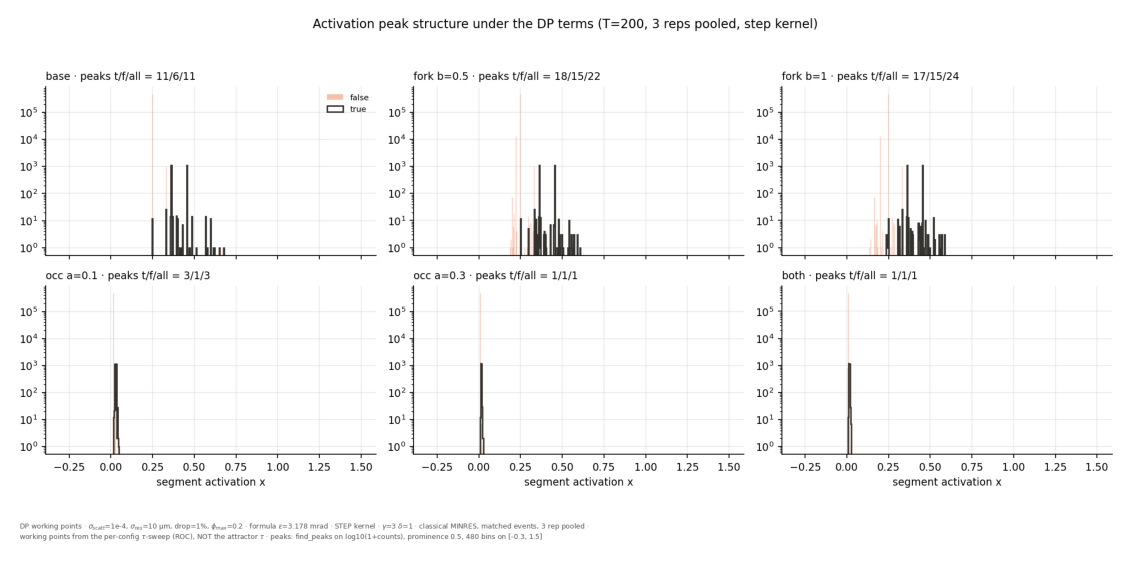

In [6]:
pk = WP.drop_duplicates(subset=["T", "config"])[
    ["T", "config", "peaks_true", "peaks_false", "peaks_all"]].dropna()
print(pk.to_string(index=False))
img = mpimg.imread(BIF / "figures" / "dp_wp_spectra_peaks.png")
fig, ax = plt.subplots(figsize=(13, 6.4)); ax.imshow(img); ax.axis("off"); plt.show()

## Answers for the FORK term (step kernel, low-but-nonzero noise)

1. **Q1 — yes at the 95%-efficiency working point, marginal at 99%.** Classically
   (median over matched events): far@eff95 drops 2.0% → 0.9% (β=0.5, T=200) with AUC
   essentially unchanged (β=0.5 slightly improves it; β≥1 starts eroding). At eff99 the
   gain is small and β≥1 hurts. **1BQF as-is: no** — wp99 far explodes 0.30 → 0.85; the
   notch misses the β-shifted spectrum (retune needed; see dp_spectrum_classical).
2. **Q2 — zero extra qubits; near-zero extra gates until density.** The ε-windowed fork
   graph is EMPTY at T ≤ 100 at this operating point (+0 pairs, +0 cx); at T=200 it adds
   2,048 pairs → ~3.7× the base 2-qubit gate count (~654k extra cx at ~319 cx/pair).
3. **Q3 — sparsity preserved.** Fill 1.02 → 1.04 at T=200; the step invariant
   (nnz < 5·n_seg) holds everywhere.
4. **Q4 — MORE distinct peaks, not fewer.** 11 → 22–24 pooled peaks at T=200: β·B_fork
   splits the degenerate chain/attractor modes into resolved sub-peaks. The spectrum
   gets more structured; the true band stays separable (AUC ~unchanged at β=0.5).

**Verdict:** the fork term is a cheap, sparsity-preserving classical purity knob at
moderate working points (β=0.5), but the current 1BQF cannot use it without retuning.